In [61]:
import pandas as pd
import numpy as np
import nltk
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from scipy.stats import kstest,anderson,skew,kurtosis

In [62]:
true=pd.read_csv('True.csv')

In [63]:
true

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"


In [64]:
fake=pd.read_csv('Fake.csv')

In [111]:
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


## Text Preprocessing On Both Fake and True 

In [65]:
fake.shape

(23481, 4)

In [66]:
true.shape

(21417, 4)

In [67]:
true['label']=1

In [68]:
fake['label']=0

In [69]:
fake

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


In [70]:
true

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1


In [71]:
df=pd.concat([fake,true],axis=0)

In [72]:
df

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1


In [73]:
df

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1


In [74]:
df_shuffled=np.random.shuffle(df.values)

In [75]:
df_shuffled

In [78]:
df

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1


In [79]:
df_shuffle=df.copy()

In [80]:
df_shuffle = df.copy()
np.random.shuffle(df_shuffle.values)

df_shuffle

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1


In [81]:
df_shuffle.drop(columns=['subject','date'],inplace=True)

In [82]:
df_shuffle

,title,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0
...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,1


In [83]:
df_shuffle['new_text']=df_shuffle['title']+' '+df_shuffle['text']

In [84]:
df_shuffle.drop(columns=['title','text'],inplace=True)

In [85]:
df_shuffle

,label,new_text
0,0,Donald Trump Sends Out Embarrassing New Year’...
1,0,Drunk Bragging Trump Staffer Started Russian ...
2,0,Sheriff David Clarke Becomes An Internet Joke...
3,0,Trump Is So Obsessed He Even Has Obama’s Name...
4,0,Pope Francis Just Called Out Donald Trump Dur...
...,...,...
21412,1,'Fully committed' NATO backs new U.S. approach...
21413,1,LexisNexis withdrew two products from Chinese ...
21414,1,Minsk cultural hub becomes haven from authorit...
21415,1,Vatican upbeat on possibility of Pope Francis ...


In [86]:
df_shuffle.isnull().sum()

label       0
new_text    0
dtype: int64

In [87]:
df_shuffle.duplicated().sum()

5793

In [88]:
df_shuffle=df_shuffle.drop_duplicates()

In [89]:
df_shuffle

,label,new_text
0,0,Donald Trump Sends Out Embarrassing New Year’...
1,0,Drunk Bragging Trump Staffer Started Russian ...
2,0,Sheriff David Clarke Becomes An Internet Joke...
3,0,Trump Is So Obsessed He Even Has Obama’s Name...
4,0,Pope Francis Just Called Out Donald Trump Dur...
...,...,...
21412,1,'Fully committed' NATO backs new U.S. approach...
21413,1,LexisNexis withdrew two products from Chinese ...
21414,1,Minsk cultural hub becomes haven from authorit...
21415,1,Vatican upbeat on possibility of Pope Francis ...


In [90]:
df_shuffle['new_text'].unique()

array([' Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America!  Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting lik

In [91]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AKASH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [92]:
from nltk.corpus import stopwords

In [93]:
stopword_eng=stopwords.words('english')
stopword_eng

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [94]:
df_shuffle['new_text']=df_shuffle['new_text'].str.lower()

C:\Users\AKASH\AppData\Local\Temp\ipykernel_13404\3216817282.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shuffle['new_text']=df_shuffle['new_text'].str.lower()


In [95]:
df_shuffle['new_text']

0         donald trump sends out embarrassing new year’...
1         drunk bragging trump staffer started russian ...
2         sheriff david clarke becomes an internet joke...
3         trump is so obsessed he even has obama’s name...
4         pope francis just called out donald trump dur...
                               ...                        
21412    'fully committed' nato backs new u.s. approach...
21413    lexisnexis withdrew two products from chinese ...
21414    minsk cultural hub becomes haven from authorit...
21415    vatican upbeat on possibility of pope francis ...
21416    indonesia to buy $1.14 billion worth of russia...
Name: new_text, Length: 39105, dtype: object

In [96]:
def remove_stopwords(token):
    filterd_tokens=[]
    token=token.split()
    for word in token:
        if word not in stopword_eng:
            filterd_tokens.append(word)
    return ' '.join(filterd_tokens)

In [97]:
import time

In [98]:
s=time.time()

df_shuffle['new_text']=df_shuffle['new_text'].apply(remove_stopwords)

e=time.time()
print(f'{e-s} seconds')

76.2098491191864 seconds


C:\Users\AKASH\AppData\Local\Temp\ipykernel_13404\29683282.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shuffle['new_text']=df_shuffle['new_text'].apply(remove_stopwords)


In [99]:
df_shuffle

,label,new_text
0,0,donald trump sends embarrassing new year’s eve...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes internet joke thr...
3,0,trump obsessed even obama’s name coded website...
4,0,pope francis called donald trump christmas spe...
...,...,...
21412,1,'fully committed' nato backs new u.s. approach...
21413,1,lexisnexis withdrew two products chinese marke...
21414,1,minsk cultural hub becomes authorities minsk (...
21415,1,vatican upbeat possibility pope francis visiti...


In [100]:
def remove_punctuations(text):
    return re.sub(r'[^\w\s]', '', text)

In [101]:
s=time.time()

df_shuffle['new_text']=df_shuffle['new_text'].apply(remove_punctuations)

e=time.time()
print(f'{e-s} seconds')

3.358677864074707 seconds


C:\Users\AKASH\AppData\Local\Temp\ipykernel_13404\3492079100.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shuffle['new_text']=df_shuffle['new_text'].apply(remove_punctuations)


In [102]:
df_shuffle['new_text']

0        donald trump sends embarrassing new years eve ...
1        drunk bragging trump staffer started russian c...
2        sheriff david clarke becomes internet joke thr...
3        trump obsessed even obamas name coded website ...
4        pope francis called donald trump christmas spe...
                               ...                        
21412    fully committed nato backs new us approach afg...
21413    lexisnexis withdrew two products chinese marke...
21414    minsk cultural hub becomes authorities minsk r...
21415    vatican upbeat possibility pope francis visiti...
21416    indonesia buy 114 billion worth russian jets j...
Name: new_text, Length: 39105, dtype: object

In [103]:
df_shuffle

,label,new_text
0,0,donald trump sends embarrassing new years eve ...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes internet joke thr...
3,0,trump obsessed even obamas name coded website ...
4,0,pope francis called donald trump christmas spe...
...,...,...
21412,1,fully committed nato backs new us approach afg...
21413,1,lexisnexis withdrew two products chinese marke...
21414,1,minsk cultural hub becomes authorities minsk r...
21415,1,vatican upbeat possibility pope francis visiti...


In [104]:
def char_count(text):
    count=0
    for ch in text:
        count+=1
    return count

s=time.time()

df_shuffle['char_count']=df_shuffle['new_text'].apply(char_count)

e=time.time()
print(f'{e-s} seconds')

6.669748783111572 seconds


C:\Users\AKASH\AppData\Local\Temp\ipykernel_13404\4208320366.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shuffle['char_count']=df_shuffle['new_text'].apply(char_count)


In [105]:
df_shuffle

,label,new_text,char_count
0,0,donald trump sends embarrassing new years eve ...,2086
1,0,drunk bragging trump staffer started russian c...,1462
2,0,sheriff david clarke becomes internet joke thr...,2642
3,0,trump obsessed even obamas name coded website ...,2055
4,0,pope francis called donald trump christmas spe...,1531
...,...,...,...
21412,1,fully committed nato backs new us approach afg...,2072
21413,1,lexisnexis withdrew two products chinese marke...,640
21414,1,minsk cultural hub becomes authorities minsk r...,1410
21415,1,vatican upbeat possibility pope francis visiti...,912


In [106]:
def word_count(text):
    text=text.split()
    return len(text)

In [107]:
df_shuffle['word_count']=df_shuffle['new_text'].apply(word_count)


C:\Users\AKASH\AppData\Local\Temp\ipykernel_13404\2187497402.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shuffle['word_count']=df_shuffle['new_text'].apply(word_count)


In [108]:
df_shuffle

,label,new_text,char_count,word_count
0,0,donald trump sends embarrassing new years eve ...,2086,303
1,0,drunk bragging trump staffer started russian c...,1462,188
2,0,sheriff david clarke becomes internet joke thr...,2642,363
3,0,trump obsessed even obamas name coded website ...,2055,277
4,0,pope francis called donald trump christmas spe...,1531,220
...,...,...,...,...
21412,1,fully committed nato backs new us approach afg...,2072,277
21413,1,lexisnexis withdrew two products chinese marke...,640,82
21414,1,minsk cultural hub becomes authorities minsk r...,1410,183
21415,1,vatican upbeat possibility pope francis visiti...,912,126


In [109]:
df_shuffle['avg_word_count']=(df_shuffle['char_count']/df_shuffle['word_count']).round(2)

C:\Users\AKASH\AppData\Local\Temp\ipykernel_13404\907757853.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shuffle['avg_word_count']=(df_shuffle['char_count']/df_shuffle['word_count']).round(2)


In [110]:
df_shuffle

,label,new_text,char_count,word_count,avg_word_count
0,0,donald trump sends embarrassing new years eve ...,2086,303,6.88
1,0,drunk bragging trump staffer started russian c...,1462,188,7.78
2,0,sheriff david clarke becomes internet joke thr...,2642,363,7.28
3,0,trump obsessed even obamas name coded website ...,2055,277,7.42
4,0,pope francis called donald trump christmas spe...,1531,220,6.96
...,...,...,...,...,...
21412,1,fully committed nato backs new us approach afg...,2072,277,7.48
21413,1,lexisnexis withdrew two products chinese marke...,640,82,7.80
21414,1,minsk cultural hub becomes authorities minsk r...,1410,183,7.70
21415,1,vatican upbeat possibility pope francis visiti...,912,126,7.24


# EDA

C:\Users\AKASH\AppData\Local\Temp\ipykernel_13404\1615124844.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_shuffle['char_count'])


<Axes: xlabel='char_count', ylabel='Density'>

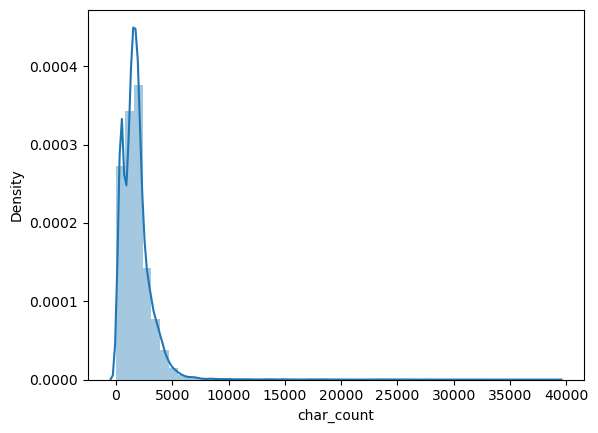

In [112]:
sns.distplot(df_shuffle['char_count'])

In [113]:
skew(df_shuffle['char_count'],)

5.519858869236017

In [114]:
kurtosis(df_shuffle['char_count'],)

86.39649077249327

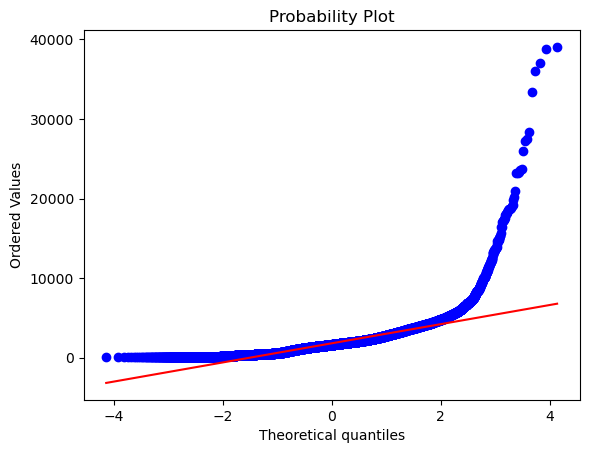

In [115]:
stats.probplot(df_shuffle['char_count'],dist='norm',plot=plt)
plt.show()

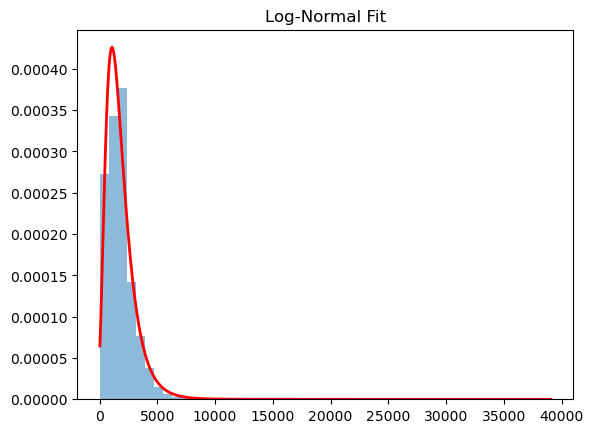

In [116]:
from scipy.stats import lognorm
import numpy as np
import matplotlib.pyplot as plt

data = df_shuffle['char_count']

shape, loc, scale = lognorm.fit(data)

x = np.linspace(min(data), max(data), 1000)
pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)

plt.hist(data, bins=50, density=True, alpha=0.5)
plt.plot(x, pdf, 'r-', lw=2)
plt.title("Log-Normal Fit")
plt.show()

In [117]:
import numpy as np

df_shuffle['char_count_log'] = np.log1p(df_shuffle['char_count'])

C:\Users\AKASH\AppData\Local\Temp\ipykernel_13404\3948355977.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shuffle['char_count_log'] = np.log1p(df_shuffle['char_count'])


C:\Users\AKASH\AppData\Local\Temp\ipykernel_13404\3311404349.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_shuffle['char_count_log'])


<Axes: xlabel='char_count_log', ylabel='Density'>

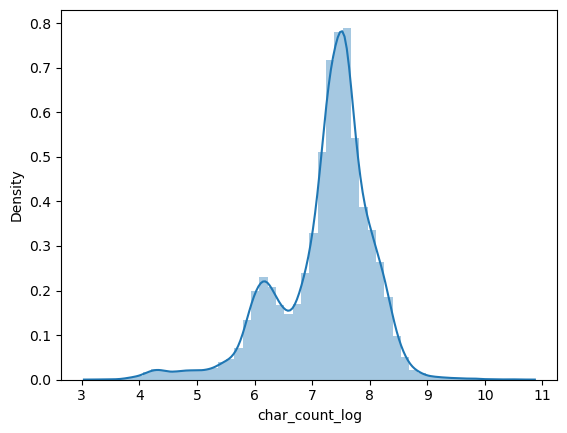

In [118]:
sns.distplot(df_shuffle['char_count_log'])

#### Interpretation
##### Before transform:
- Highly right-skewed
- Long tail 
- Not suitable for many models

##### After log transform:
- Nearly normal distribution
- Reduced skewness
- Better for ML models

In [119]:
skew(df_shuffle['char_count_log'])

-1.0304703967694808

In [120]:
kurtosis(df_shuffle['char_count_log'])

1.7824122859322706

In [121]:
# ks test on 

h0='char_count column follows the normal distribution'
h1='char_count column does NOT follow normal distribution'

print(f'h0 : {h0}')
print(f'h1: {h1}\n')

x=df_shuffle['char_count']
z_val=(x - x.mean()) / x.std()
Statistic,pvalue=stats.kstest(z_val,'norm')
print(f'Statistic :{Statistic}\npvalue :{pvalue}\n')

if pvalue>0.05:
    print('Fail to reject H0 (char_count distribution fits normal distribution)')
else:
    print('Reject H0 (char_count distribution does NOT fit normal distribution)')

h0 : char_count column follows the normal distribution
h1: char_count column does NOT follow normal distribution

Statistic :0.12369196973404151
pvalue :0.0

Reject H0 (char_count distribution does NOT fit normal distribution)


In [122]:
# ks test on char_count_log

h0='char_count_log column follows the normal distribution'
h1='char_count_log column does NOT follow normal distribution'

print(f'h0 : {h0}')
print(f'h1: {h1}\n')

x=df_shuffle['char_count_log']
z_val=(x - x.mean()) / x.std()
Statistic,pvalue=stats.kstest(z_val,'norm')
print(f'Statistic :{Statistic}\npvalue :{pvalue}\n')

if pvalue>0.05:
    print('Fail to reject H0 (char_count_log distribution fits normal distribution)')
else:
    print('Reject H0 (char_count_log distribution does NOT fit normal distribution)')

h0 : char_count_log column follows the normal distribution
h1: char_count_log column does NOT follow normal distribution

Statistic :0.12286212153190473
pvalue :0.0

Reject H0 (char_count_log distribution does NOT fit normal distribution)


In [123]:
#anderson on char_count data

h0='char_count column follows the normal distribution'
h1='char_count column does NOT follow normal distribution'

print(f'h0 : {h0}')
print(f'h1: {h1}\n')

x=df_shuffle['char_count']
Statistic,critical_values,significance_level =stats.anderson(x,'norm')
print(f' Statistic :{Statistic}\n critical_values:{critical_values} \n significance_level  :{significance_level }')

print('\t')

for i,j in zip(critical_values,significance_level):
    if i>Statistic:
        print(f"At {j}% significance level i.e H0 ACCEPTED (char_count column Fits normal distribution)")
    else:
        print(f"At {j}% significance level i.e H0 REJECTED (char_count column Not normally distributed)")

h0 : char_count column follows the normal distribution
h1: char_count column does NOT follow normal distribution

 Statistic :1181.5541229027804
 critical_values:[0.576 0.656 0.787 0.918 1.092] 
 significance_level  :[15.  10.   5.   2.5  1. ]
	
At 15.0% significance level i.e H0 REJECTED (char_count column Not normally distributed)
At 10.0% significance level i.e H0 REJECTED (char_count column Not normally distributed)
At 5.0% significance level i.e H0 REJECTED (char_count column Not normally distributed)
At 2.5% significance level i.e H0 REJECTED (char_count column Not normally distributed)
At 1.0% significance level i.e H0 REJECTED (char_count column Not normally distributed)


In [124]:
#anderson on char_count_log data

h0='char_count_log column follows the normal distribution'
h1='char_count_log column does NOT follow normal distribution'

print(f'h0 : {h0}')
print(f'h1: {h1}\n')

x=df_shuffle['char_count_log']
Statistic,critical_values,significance_level =stats.anderson(x,'norm')
print(f' Statistic :{Statistic}\n critical_values:{critical_values} \n significance_level  :{significance_level }')

print('\t')

for i,j in zip(critical_values,significance_level):
    if i>Statistic:
        print(f"At {j}% significance level i.e H0 ACCEPTED (char_count_log column Fits normal distribution)")
    else:
        print(f"At {j}% significance level i.e H0 REJECTED (char_count_log column Not normally distributed)")

h0 : char_count_log column follows the normal distribution
h1: char_count_log column does NOT follow normal distribution

 Statistic :810.1170686247133
 critical_values:[0.576 0.656 0.787 0.918 1.092] 
 significance_level  :[15.  10.   5.   2.5  1. ]
	
At 15.0% significance level i.e H0 REJECTED (char_count_log column Not normally distributed)
At 10.0% significance level i.e H0 REJECTED (char_count_log column Not normally distributed)
At 5.0% significance level i.e H0 REJECTED (char_count_log column Not normally distributed)
At 2.5% significance level i.e H0 REJECTED (char_count_log column Not normally distributed)
At 1.0% significance level i.e H0 REJECTED (char_count_log column Not normally distributed)


<Axes: xlabel='label', ylabel='char_count'>

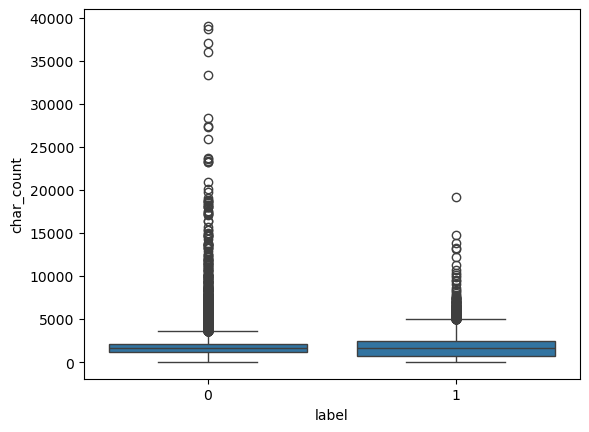

In [125]:
sns.boxplot(x=df_shuffle['label'], y=df_shuffle['char_count'])


### Fake News (label = 1)
- Has more extreme outliers
- Some articles are very long (up to ~40k characters)

Fake news often:
- Adds extra content and exaggeration
- Uses long narratives to persuade

### True News (label = 0)
- More consistent in length
- Fewer extreme values

Real news tends to be:
- Concise
- Structured

### Median Comparison
- Both classes have similar median values

This means:
- Length alone cannot clearly separate fake vs real news

## Final Conclusion

- Fake news tends to have higher variability and more extreme lengths, but there is significant overlap between the two classes.
- Therefore, char_count alone is not a strong predictor for distinguishing fake news from real news.

<Axes: xlabel='label', ylabel='char_count'>

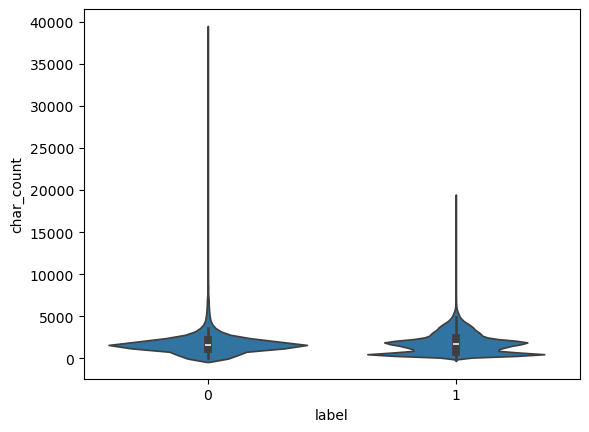

In [126]:
sns.violinplot(x=df_shuffle['label'], y=df_shuffle['char_count'])

## Analysis of char_count using Violin Plot

### Distribution Shape

- Both label 0 and label 1 show right-skewed distributions
- Most data points are concentrated in lower char_count ranges
- Long tails indicate presence of very large values

### Fake News (label = 1)

- Wider distribution compared to label 0
- Higher density in mid to higher char_count values
- Longer tail, indicating more extreme values

### True News (label = 0)

- Narrower distribution
- More concentrated around lower char_count values
- Fewer extreme values compared to label 1

### Density Comparison

- Label 1 has more spread, indicating higher variability
- Label 0 is more compact, showing consistency in length

### Overlap

- Significant overlap between both classes
- Many values fall in similar ranges for both labels

### Final Conclusion

The violin plot shows that fake news tends to have higher variability and more extreme lengths, while true news is more consistent. However, due to the strong overlap between distributions, char_count alone is not sufficient to distinguish between fake and true news.

C:\Users\AKASH\AppData\Local\Temp\ipykernel_13404\4247886260.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_shuffle['word_count'])


<Axes: xlabel='word_count', ylabel='Density'>

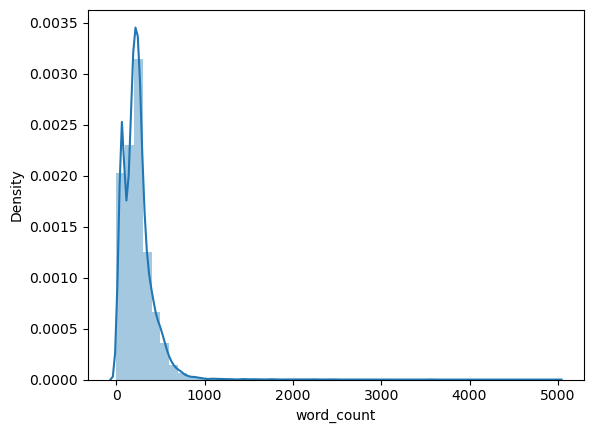

In [127]:
sns.distplot(df_shuffle['word_count'])

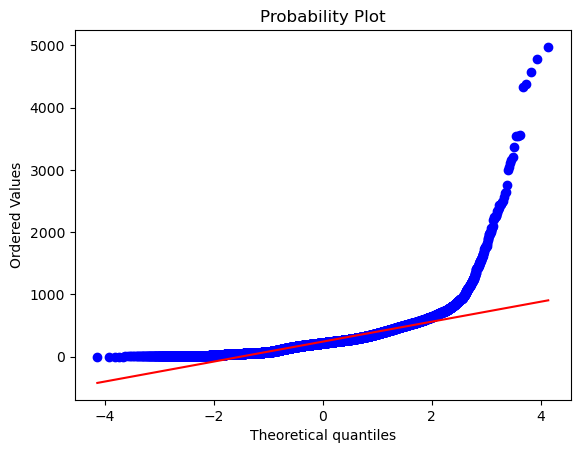

In [128]:
stats.probplot(df_shuffle['word_count'],dist='norm',plot=plt)
plt.show()

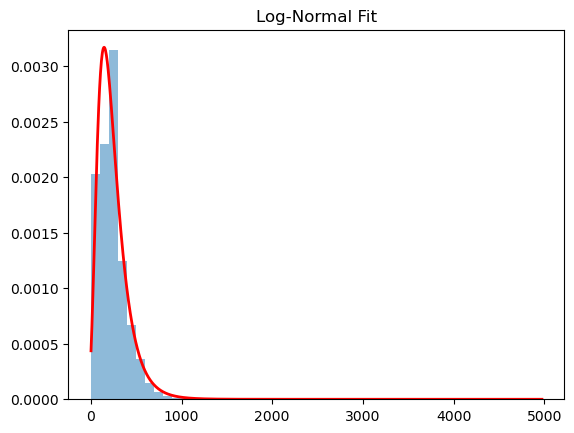

In [129]:
from scipy.stats import lognorm
import numpy as np
import matplotlib.pyplot as plt

data = df_shuffle['word_count']

shape, loc, scale = lognorm.fit(data)

x = np.linspace(min(data), max(data), 1000)
pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)

plt.hist(data, bins=50, density=True, alpha=0.5)
plt.plot(x, pdf, 'r-', lw=2)
plt.title("Log-Normal Fit")
plt.show()

In [130]:
skew(df_shuffle['word_count'])

5.0947994068324425

In [131]:
kurtosis(df_shuffle['word_count'])

73.82579745348116

In [132]:
a=np.log(df_shuffle['word_count'])

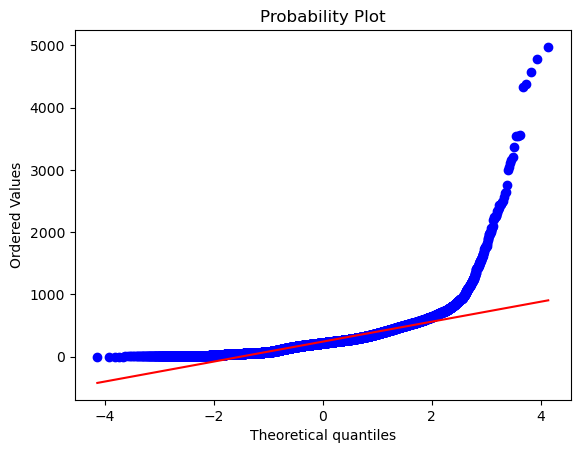

In [133]:
stats.probplot(df_shuffle['word_count'],dist='norm',plot=plt)
plt.show()

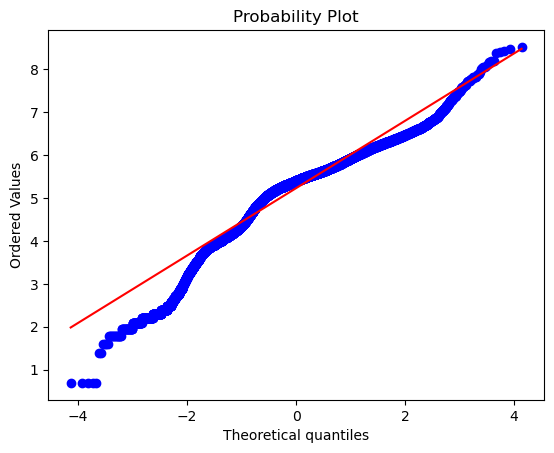

In [134]:
stats.probplot(a,dist='norm',plot=plt)
plt.show()

<Axes: xlabel='label', ylabel='word_count'>

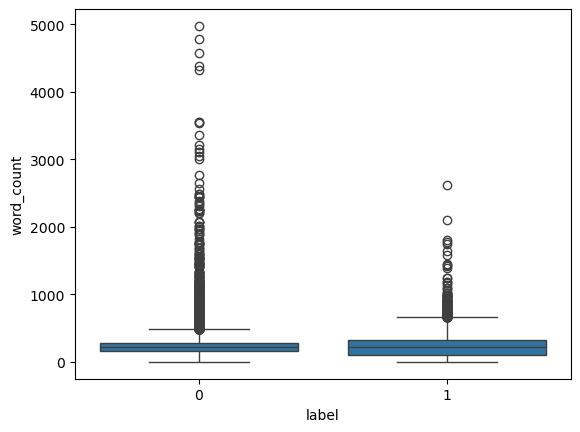

In [135]:
sns.boxplot(x=df_shuffle['label'],y=df_shuffle['word_count'])

### Central Tendency
The median word_count for label 1 is slightly higher than label 0. This indicates that fake news articles tend to be marginally longer on average compared to true news.

### Spread and Variability

Label 1 shows a wider interquartile range (IQR), meaning fake news has greater variability in article length. Label 0 is more compact, suggesting more consistency in word counts for true news.

### Outliers

Both classes contain outliers, but:
- Label 1 has significantly more extreme outliers
- Some fake news articles exceed 5000 words
- Label 0 outliers are fewer and less extreme (mostly below ~3000)

This suggests fake news includes unusually long articles more frequently.

### Distribution Shape

Both distributions are right-skewed:
- Most articles are short
- A small number of very long articles stretch the upper range
- Skewness is stronger in label 1

### Key Insights

Fake news tends to be slightly longer and much more variable in length  
True news is more consistent and less extreme in word count  
Extreme long-form content is more associated with fake news  

### Conclusion

The word_count feature shows clear differences between the two classes, with fake news exhibiting higher variability and more extreme long-form articles, making it a potentially informative feature for classification tasks

C:\Users\AKASH\AppData\Local\Temp\ipykernel_13404\3743260612.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_shuffle['avg_word_count'])


<Axes: xlabel='avg_word_count', ylabel='Density'>

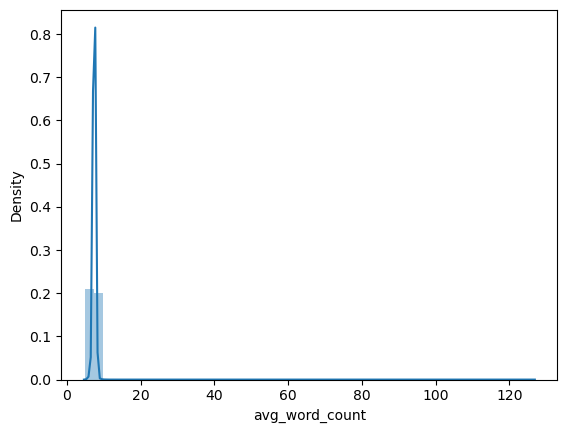

In [136]:
sns.distplot(df_shuffle['avg_word_count'])
plt.so

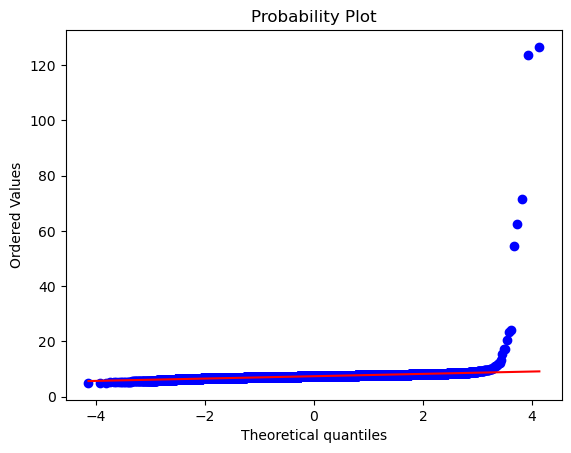

In [137]:
stats.probplot(df_shuffle['avg_word_count'], dist='norm', plot=plt)
plt.show()